# Adaptive grids

`AdaptiveHypergrid` extends the standard grid with automatic rebinning:
when the fraction of data points that fall outside the current grid boundaries
exceeds `drift_threshold`, it recomputes the edges from a rolling buffer of
recent points and rebuilds the histogram.

This makes it suitable for streaming data where the distribution shifts over time.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from hypergrid import AdaptiveHypergrid

## 1. Creating an adaptive grid (edges computed automatically)

In [2]:
rng = np.random.default_rng(42)

grid = AdaptiveHypergrid(
    drift_threshold=0.05,  # rebin when >5% overflow
    buffer_size=2000,      # keep last 2000 points for rebinning
    binning_method="fd",
    max_bins=30,
)

# Fit on first batch — edges computed from this data
batch1 = rng.standard_normal((1000, 2))
grid.fit(batch1)

print(f"Edges after fit:")
for d, e in enumerate(grid.get_edges()):
    print(f"  dim {d}: {len(e)-1} bins  [{e[0]:.2f}, {e[-1]:.2f}]")

Edges after fit:
  dim 0: 24 bins  [-2.96, 3.18]
  dim 1: 25 bins  [-3.65, 2.91]


## 2. Simulating concept drift

In [3]:
n_steps = 20
drift_per_step = 0.5   # mean shifts by 0.5 each step
rebin_events = []

for step in range(n_steps):
    n_rebins_before = len(grid._drift_history)

    # Data distribution shifts progressively
    mean_shift = step * drift_per_step
    batch = rng.standard_normal((200, 2)) + mean_shift
    grid.update(batch)

    if len(grid._drift_history) > n_rebins_before:
        rebin_events.append(step)
        print(f"  Step {step:2d}: rebin triggered  "
              f"(overflow fraction {grid._drift_history[-1]:.1%})")

print(f"\nTotal rebins: {len(grid._drift_history)}")

  Step  5: rebin triggered  (overflow fraction 8.5%)
  Step 11: rebin triggered  (overflow fraction 8.0%)
  Step 15: rebin triggered  (overflow fraction 5.2%)

Total rebins: 3


## 3. Drift history

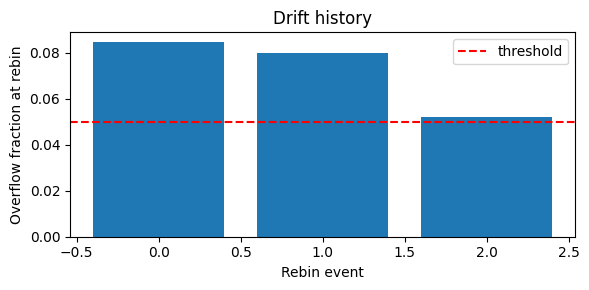

In [4]:
if grid._drift_history:
    plt.figure(figsize=(6, 3))
    plt.bar(range(len(grid._drift_history)), grid._drift_history)
    plt.axhline(grid.drift_threshold, color="red", linestyle="--", label="threshold")
    plt.xlabel("Rebin event")
    plt.ylabel("Overflow fraction at rebin")
    plt.title("Drift history")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No rebins occurred — try increasing drift_per_step or decreasing drift_threshold.")

## 4. Grid after drift — edges adapted to recent data

Final edges:
  dim 0: 26 bins  [-0.14, 10.25]
  dim 1: 29 bins  [-0.11, 11.53]


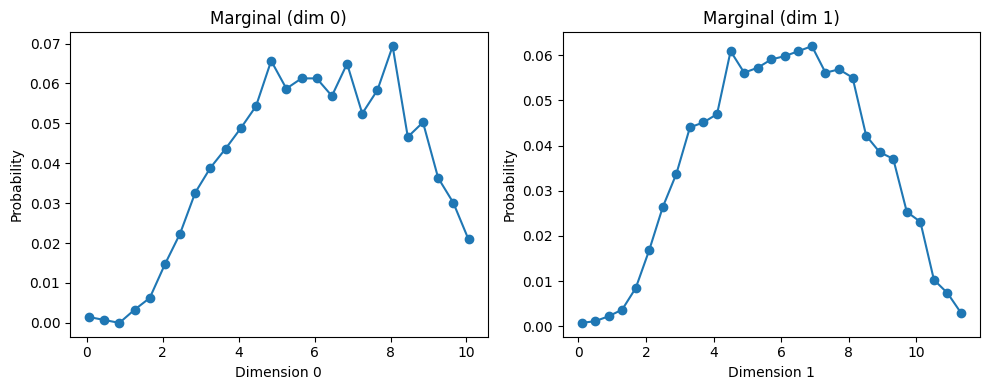

In [5]:
print("Final edges:")
for d, e in enumerate(grid.get_edges()):
    print(f"  dim {d}: {len(e)-1} bins  [{e[0]:.2f}, {e[-1]:.2f}]")

grid.plot_all_marginals()

## 5. Using pre-specified initial edges

You can provide initial edges — the grid will still rebin automatically when overflow exceeds the threshold.

In [6]:
initial_edges = [np.linspace(-3, 3, 13), np.linspace(-3, 3, 13)]

grid2 = AdaptiveHypergrid(edges=initial_edges, drift_threshold=0.05)
grid2.fit(rng.standard_normal((500, 2)))
print(f"Non-empty bins: {len(grid2.get_mass())}")

Non-empty bins: 151
